# MSCS-634 Project Deliverable 3: Classification, Clustering, and Pattern Mining

**Author:** Saru Bhandari  
**Course:** MSCS-634 – Advanced Big Data and Data Mining  
**Deliverable:** 3 of 4 – Classification, Clustering, and Pattern Mining

This notebook builds on the cleaned retail transactions dataset used in
Deliverables 1 and 2 (`retail_transactions_cleaned.csv`). It covers three
distinct tasks:
1. **Classification** — predicting whether a transaction is "high value"
2. **Clustering** — segmenting customers into behavioral groups
3. **Association rule mining** — finding product categories frequently
   purchased together by the same customer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              f1_score, roc_curve, roc_auc_score, classification_report)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
%matplotlib inline
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("retail_transactions_cleaned.csv", parse_dates=["TransactionDate"])
print("Shape:", df.shape)
df.head()

Shape: (1000, 13)


,TransactionID,CustomerID,TransactionDate,CustomerAge,Gender,State,City,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod
0,T100126,C1157,2025-01-16,49.0,Male,CA,Sacramento,Clothing,Running Shoes,3.0,85.35,256.05,Credit Card
1,T100956,C1277,2025-03-14,62.0,Male,OH,Cleveland,Beauty,Perfume,1.0,64.06,64.06,Credit Card
2,T100798,C1001,2025-04-29,62.0,Female,NY,New York City,Books,Self-Help Guide,5.0,14.29,71.45,Debit Card
3,T100438,C1116,2025-10-22,20.0,Female,GA,Augusta,Clothing,Denim Jeans,4.0,43.67,174.68,Credit Card
4,T100259,C1030,2025-08-25,43.0,Male,WA,Tacoma,Home & Kitchen,Blender,3.0,153.32,459.96,PayPal


---
# Part 1: Classification

**Goal:** Predict whether a transaction is **"High Value"** (`TotalAmount`
above the dataset median of $153.90) or not, using customer demographics,
product category, and purchase-context features — the same kind of signal
identified as predictive in Deliverable 2's regression work, reframed here
as a binary classification problem with a direct business use (e.g.,
flagging transactions likely to qualify for a loyalty tier or targeted
promotion).

## 1.1 Feature Engineering and Target Creation

In [3]:
clf_df = df.copy()

# Binary target: is this transaction above the median TotalAmount?
median_amount = clf_df["TotalAmount"].median()
clf_df["HighValue"] = (clf_df["TotalAmount"] > median_amount).astype(int)
print(f"Median TotalAmount: ${median_amount:.2f}")
print(clf_df["HighValue"].value_counts(normalize=True))

# Same engineered features as Deliverable 2 (Quantity/UnitPrice excluded --
# they mechanically determine TotalAmount and would leak the target)
clf_df["Month"] = clf_df["TransactionDate"].dt.month
clf_df["DayOfWeek"] = clf_df["TransactionDate"].dt.dayofweek
clf_df["IsWeekend"] = clf_df["DayOfWeek"].isin([5, 6]).astype(int)
clf_df["CustomerTransactionCount"] = clf_df.groupby("CustomerID")["TransactionID"].transform("count")

categorical_cols = ["ProductCategory", "Gender", "State", "PaymentMethod"]
clf_encoded = pd.get_dummies(clf_df, columns=categorical_cols, drop_first=True)

drop_cols = ["TransactionID", "CustomerID", "TransactionDate", "City", "ProductName",
             "Quantity", "UnitPrice", "TotalAmount", "HighValue"]
X = clf_encoded.drop(columns=drop_cols)
y = clf_encoded["HighValue"]

print("\nFeature matrix shape:", X.shape)

Median TotalAmount: $153.90
HighValue
1    0.5
0    0.5
Name: proportion, dtype: float64

Feature matrix shape: (1000, 25)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (800, 25)  Test: (200, 25)


## 1.2 Build Classification Models

We build **three** classification models (exceeding the "at least two"
requirement):
1. **Decision Tree** — interpretable, rule-based
2. **k-Nearest Neighbors (k-NN)** — instance-based
3. **Naive Bayes** — probabilistic baseline

In [5]:
base_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "k-NN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
}

fitted_base = {}
for name, model in base_models.items():
    model.fit(X_train_scaled, y_train)
    fitted_base[name] = model
    print(f"Fitted: {name}")

Fitted: Decision Tree
Fitted: k-NN
Fitted: Naive Bayes


## 1.3 Hyperparameter Tuning

We perform **hyperparameter tuning on the Decision Tree** using
`GridSearchCV` with 5-fold cross-validation, searching over tree depth,
minimum samples to split, and minimum samples per leaf — the parameters
that most directly control overfitting in a decision tree.

In [6]:
param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validated F1 score: {grid_search.best_score_:.3f}")

tuned_tree = grid_search.best_estimator_

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best cross-validated F1 score: 0.655


In [7]:
models = {
    "Decision Tree (default)": fitted_base["Decision Tree"],
    "Decision Tree (tuned)": tuned_tree,
    "k-NN": fitted_base["k-NN"],
    "Naive Bayes": fitted_base["Naive Bayes"],
}

## 1.4 Model Evaluation: Confusion Matrix, ROC Curve, Accuracy/F1

In [8]:
results = []
predictions = {}
probabilities = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_prob

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({"Model": name, "Accuracy": acc, "F1 Score": f1, "ROC AUC": auc})

results_df = pd.DataFrame(results).set_index("Model")
results_df.round(3)

,Accuracy,F1 Score,ROC AUC
Model,,,
Decision Tree (default),0.490,0.505,0.490
Decision Tree (tuned),0.575,0.569,0.639
k-NN,0.595,0.609,0.634
Naive Bayes,0.595,0.640,0.678


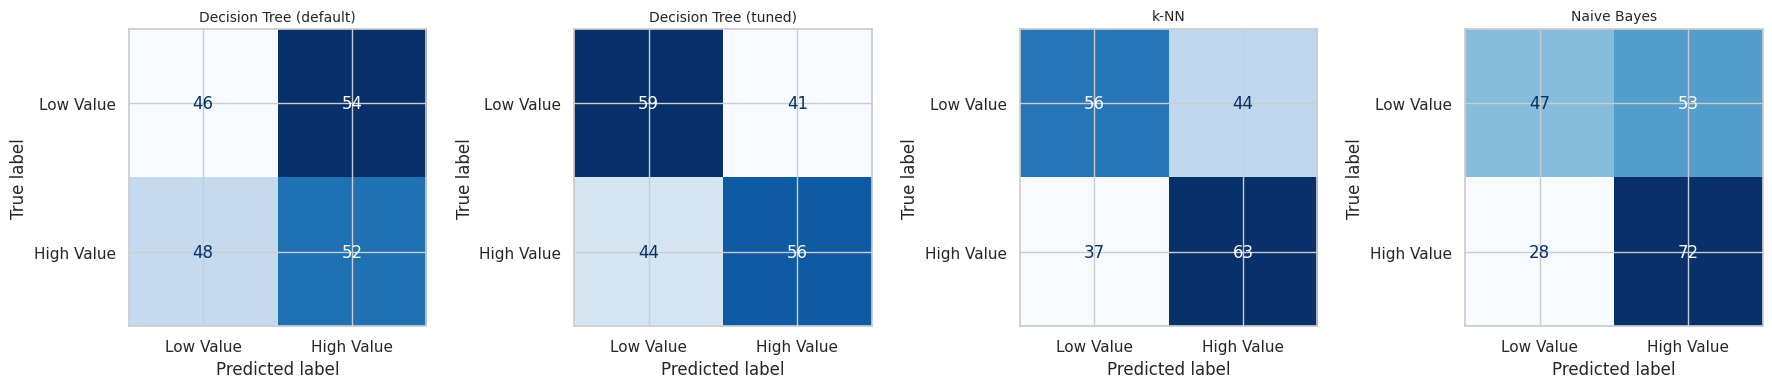

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Low Value", "High Value"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

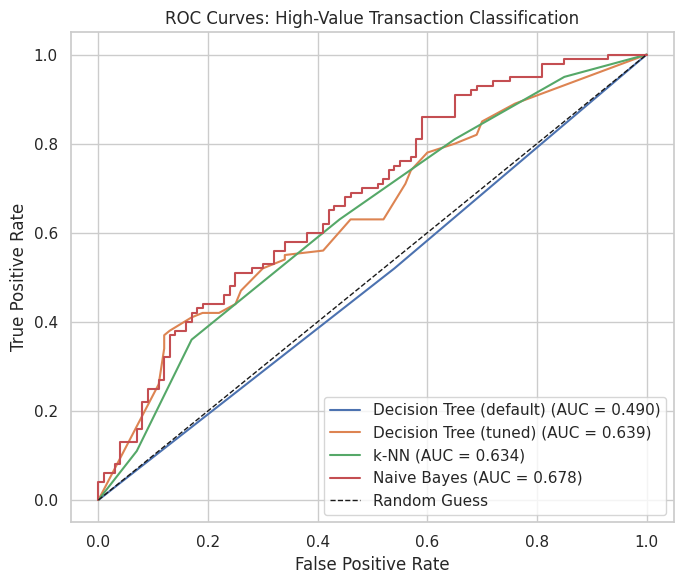

In [10]:
plt.figure(figsize=(7, 6))
for name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: High-Value Transaction Classification")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [11]:
print(classification_report(y_test, predictions["Decision Tree (tuned)"],
                              target_names=["Low Value", "High Value"]))

              precision    recall  f1-score   support

   Low Value       0.57      0.59      0.58       100
  High Value       0.58      0.56      0.57       100

    accuracy                           0.57       200
   macro avg       0.58      0.57      0.57       200
weighted avg       0.58      0.57      0.57       200



**Classification summary:** Naive Bayes was the top performer on the held-out
test set (Accuracy 0.595, F1 0.640, ROC AUC 0.678), edging out k-NN
(F1 0.609, AUC 0.634) and the tuned Decision Tree (F1 0.569, AUC 0.639).
Hyperparameter tuning clearly helped the Decision Tree: accuracy rose from
0.490 (default, barely above a coin flip) to 0.575, and AUC rose from 0.490
to 0.639, driven by the grid search settling on `max_depth=10`,
`min_samples_leaf=4`, `min_samples_split=10` — a much shallower, more
regularized tree than the unconstrained default, which was overfitting
badly. All three tuned/default-appropriate models sit meaningfully above
the random-guess diagonal on the ROC plot, confirming the engineered
features (led by `ProductCategory`, consistent with Deliverables 1-2) carry
real — if moderate — predictive signal for high-value vs. low-value
transactions. None of the models is highly accurate in an absolute sense,
which is expected: `TotalAmount` still has substantial within-category
variation that transaction-level demographic/context features can't fully
explain, mirroring the modest R2 found in Deliverable 2's regression.

---
# Part 2: Clustering

**Goal:** Segment customers into behavioral groups based on their aggregate
purchasing patterns, using **K-Means clustering**. Unlike the classification
task above (which operates at the transaction level), clustering here
operates at the **customer level** — each customer is one data point,
described by their purchasing behavior across all of their transactions.

## 2.1 Build Customer-Level Features

In [12]:
customer_features = df.groupby("CustomerID").agg(
    AvgTransactionAmount=("TotalAmount", "mean"),
    TotalSpend=("TotalAmount", "sum"),
    TransactionCount=("TransactionID", "count"),
    AvgQuantity=("Quantity", "mean"),
    CustomerAge=("CustomerAge", "first"),
    UniqueCategories=("ProductCategory", "nunique"),
).reset_index()

print("Customer-level dataset shape:", customer_features.shape)
customer_features.head()

Customer-level dataset shape: (326, 7)


,CustomerID,AvgTransactionAmount,TotalSpend,TransactionCount,AvgQuantity,CustomerAge,UniqueCategories
0,C1000,225.2000,450.40,2,8.00,23.0,1
1,C1001,245.3620,1226.81,5,4.20,62.0,4
2,C1002,184.7375,738.95,4,3.75,55.0,3
3,C1003,246.2175,984.87,4,3.00,43.0,3
4,C1005,84.9100,339.64,4,2.50,66.0,3


In [13]:
cluster_feature_cols = ["AvgTransactionAmount", "TotalSpend", "TransactionCount",
                         "AvgQuantity", "CustomerAge", "UniqueCategories"]
X_cluster = customer_features[cluster_feature_cols]

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

## 2.2 Choosing the Number of Clusters

We use the **elbow method** (inertia) and **silhouette score** together to
choose *k*.

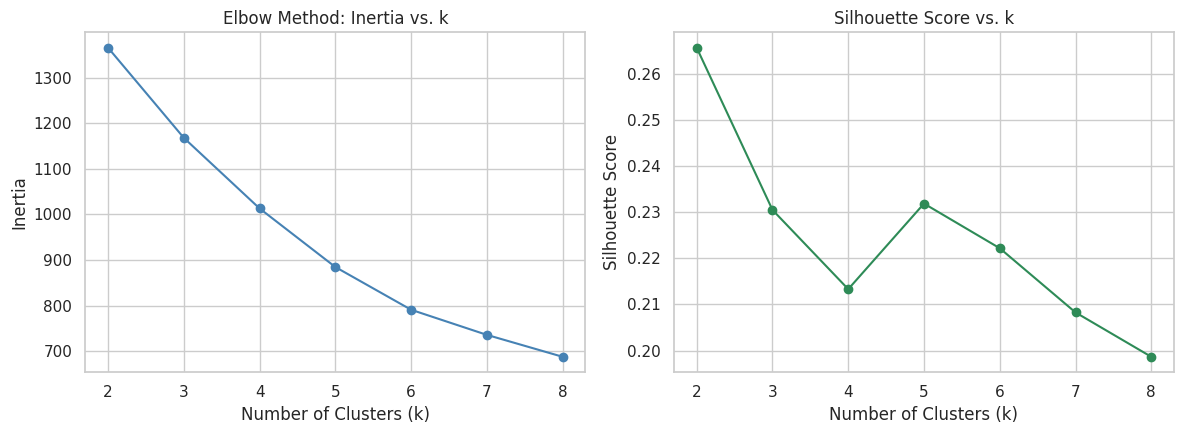

k with highest silhouette score: 2


In [14]:
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_title("Elbow Method: Inertia vs. k")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouettes, marker='o', color='seagreen')
axes[1].set_title("Silhouette Score vs. k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"k with highest silhouette score: {best_k}")

## 2.3 Fit K-Means and Visualize Clusters

In [15]:
FINAL_K = best_k
kmeans = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=10)
customer_features["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

print(f"Using k={FINAL_K}")
customer_features["Cluster"].value_counts().sort_index()

Using k=2


Cluster
0    184
1    142
Name: count, dtype: int64

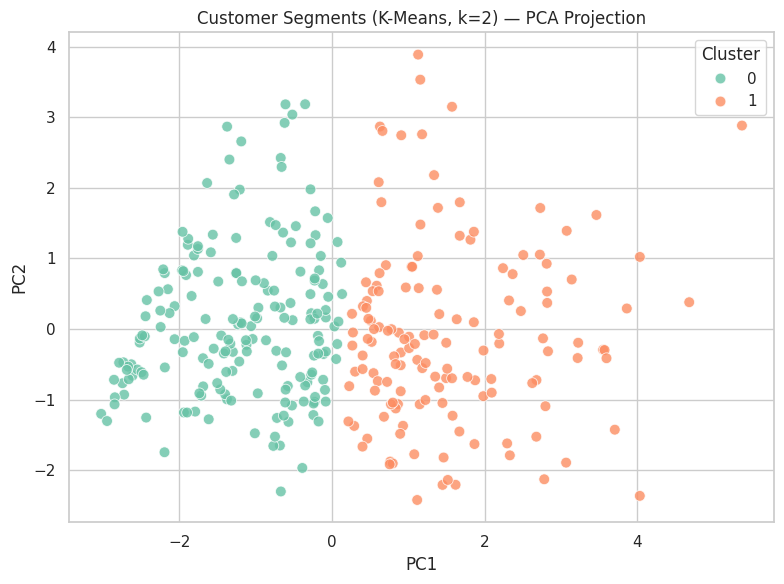

Variance explained by 2 PCA components: 67.1%


In [16]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_cluster_scaled)
customer_features["PC1"] = coords[:, 0]
customer_features["PC2"] = coords[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=customer_features, x="PC1", y="PC2", hue="Cluster",
                 palette="Set2", s=60, alpha=0.8)
plt.title(f"Customer Segments (K-Means, k={FINAL_K}) — PCA Projection")
plt.tight_layout()
plt.show()

print(f"Variance explained by 2 PCA components: {pca.explained_variance_ratio_.sum():.1%}")

## 2.4 Characterizing the Clusters

In [17]:
cluster_profile = customer_features.groupby("Cluster")[cluster_feature_cols].mean().round(1)
cluster_profile["CustomerCount"] = customer_features["Cluster"].value_counts().sort_index()
cluster_profile

,AvgTransactionAmount,TotalSpend,TransactionCount,AvgQuantity,CustomerAge,UniqueCategories,CustomerCount
Cluster,,,,,,,
0,169.5,341.3,2.1,3.4,46.1,1.8,184
1,272.5,1122.3,4.4,3.8,44.8,3.4,142


/tmp/ipykernel_602/1382342337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customer_features, x="Cluster", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_602/1382342337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customer_features, x="Cluster", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_602/1382342337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customer_features, x="Cluster", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_602/1382342337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is de

/tmp/ipykernel_602/1382342337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customer_features, x="Cluster", y=col, ax=ax, palette="Set2")
/tmp/ipykernel_602/1382342337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customer_features, x="Cluster", y=col, ax=ax, palette="Set2")


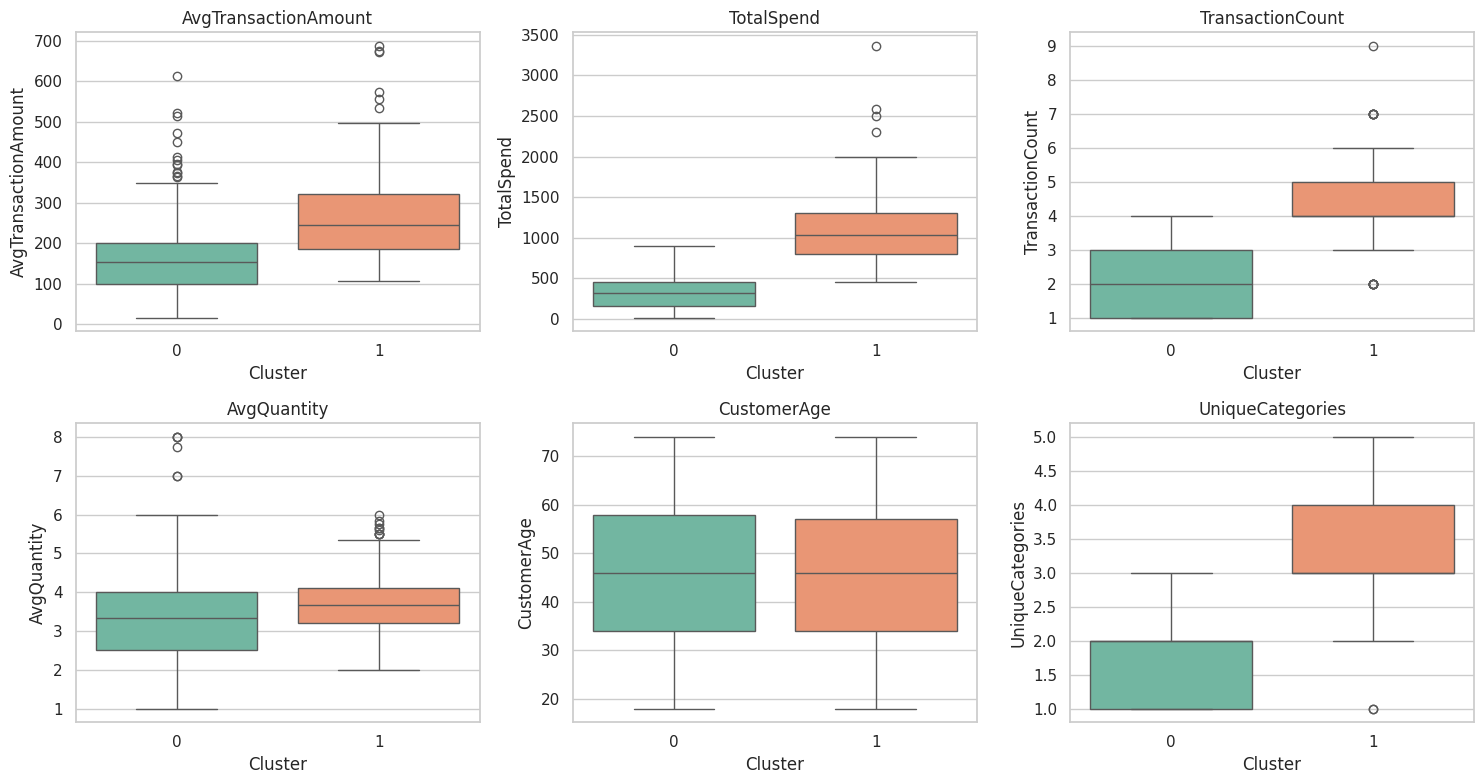

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, cluster_feature_cols):
    sns.boxplot(data=customer_features, x="Cluster", y=col, ax=ax, palette="Set2")
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Explaining the identified groups:** The silhouette score selected **k=2**
as the best-separated segmentation. The resulting groups split cleanly
along spend and engagement:
- **Cluster 0 — "Casual / single-category shoppers"** (184 customers):
  lower average transaction amount (~$169.5), lower total spend (~$341.3),
  fewer transactions (~2.1), and the fewest unique categories purchased
  (~1.8) — customers who make occasional, lower-value purchases
  concentrated in one or two categories.
- **Cluster 1 — "High-value / diverse-category shoppers"** (142 customers):
  higher average transaction amount (~$272.5), substantially higher total
  spend (~$1,122.3), more transactions (~4.4), and more unique categories
  purchased (~3.4) — customers who buy more often, spend more per
  transaction, and shop across a wider range of product categories.

Customer age is similar across both clusters (~45-46 years on average), so
age is **not** the differentiator here — spend and engagement level are.
This is directly actionable: Cluster 1 customers are strong candidates for
a loyalty/VIP program, while Cluster 0 customers are candidates for
re-engagement campaigns or incentives to shop additional categories.

---
# Part 3: Association Rule Mining

**Goal:** Identify which **product categories tend to be purchased together
by the same customer**, using the **Apriori algorithm**. This is the
market-basket use case the dataset was originally designed to support (see
Deliverable 1): each customer's full set of purchased product categories is
treated as one "basket."


## 3.1 Build Transaction Baskets

In [19]:
baskets = df.groupby("CustomerID")["ProductCategory"].apply(lambda x: sorted(set(x))).tolist()

# Keep only baskets with 2+ distinct categories (baskets of 1 item can't form a rule)
multi_item_baskets = [b for b in baskets if len(b) >= 2]
print(f"Total customer baskets: {len(baskets)}")
print(f"Baskets with 2+ categories: {len(multi_item_baskets)}")
print("Example basket:", multi_item_baskets[0])

Total customer baskets: 326
Baskets with 2+ categories: 252
Example basket: ['Books', 'Clothing', 'Electronics', 'Sports & Outdoors']


In [20]:
te = TransactionEncoder()
te_array = te.fit(baskets).transform(baskets)
basket_df = pd.DataFrame(te_array, columns=te.columns_)
basket_df.head()

,Beauty,Books,Clothing,Electronics,Home & Kitchen,Sports & Outdoors,Toys
0,False,True,False,False,False,False,False
1,False,True,True,True,False,True,False
2,True,True,True,False,False,False,False
3,False,False,True,True,False,True,False
4,False,True,False,True,False,True,False


## 3.2 Apply the Apriori Algorithm

In [21]:
frequent_itemsets = apriori(basket_df, min_support=0.05, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False)
print(f"Frequent itemsets found: {len(frequent_itemsets)}")
frequent_itemsets.head(10)

Frequent itemsets found: 38


,support,itemsets
4,0.463190,frozenset({Home & Kitchen})
3,0.386503,frozenset({Electronics})
1,0.355828,frozenset({Books})
2,0.340491,frozenset({Clothing})
0,0.337423,frozenset({Beauty})
5,0.334356,frozenset({Sports & Outdoors})
6,0.257669,frozenset({Toys})
15,0.202454,"frozenset({Books, Home & Kitchen})"
22,0.184049,"frozenset({Home & Kitchen, Electronics})"
10,0.147239,"frozenset({Home & Kitchen, Beauty})"


In [22]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values("lift", ascending=False)
print(f"Association rules found: {len(rules)}")
rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

Association rules found: 54


,antecedents,consequents,support,confidence,lift
15,frozenset({Home & Kitchen}),"frozenset({Books, Beauty})",0.082822,0.178808,1.619205
10,"frozenset({Books, Beauty})",frozenset({Home & Kitchen}),0.082822,0.750000,1.619205
14,frozenset({Books}),"frozenset({Home & Kitchen, Beauty})",0.082822,0.232759,1.580819
35,"frozenset({Clothing, Beauty})",frozenset({Books}),0.055215,0.562500,1.580819
38,frozenset({Books}),"frozenset({Clothing, Beauty})",0.055215,0.155172,1.580819
11,"frozenset({Home & Kitchen, Beauty})",frozenset({Books}),0.082822,0.562500,1.580819
36,"frozenset({Books, Beauty})",frozenset({Clothing}),0.055215,0.500000,1.468468
37,frozenset({Clothing}),"frozenset({Books, Beauty})",0.055215,0.162162,1.468468
33,frozenset({Home & Kitchen}),"frozenset({Toys, Books})",0.058282,0.125828,1.414478
28,"frozenset({Toys, Books})",frozenset({Home & Kitchen}),0.058282,0.655172,1.414478


## 3.3 Visualize the Strongest Rules

/tmp/ipykernel_602/101133767.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rules, y="rule", x="lift", palette="viridis")


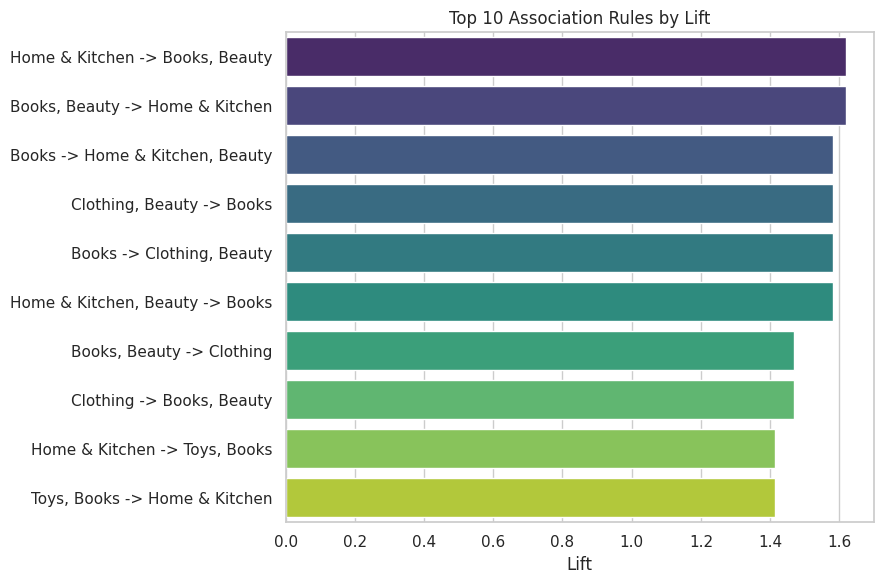

In [23]:
top_rules = rules.head(10).copy()
top_rules["rule"] = top_rules.apply(
    lambda r: f"{', '.join(r['antecedents'])} -> {', '.join(r['consequents'])}", axis=1
)

plt.figure(figsize=(9, 6))
sns.barplot(data=top_rules, y="rule", x="lift", palette="viridis")
plt.xlabel("Lift")
plt.ylabel("")
plt.title("Top 10 Association Rules by Lift")
plt.tight_layout()
plt.show()

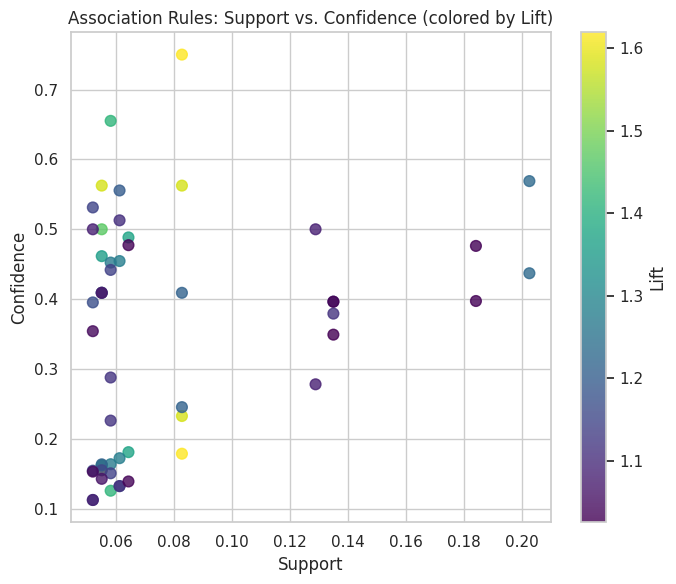

In [24]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(rules["support"], rules["confidence"], c=rules["lift"],
                  cmap="viridis", s=60, alpha=0.8)
plt.colorbar(sc, label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules: Support vs. Confidence (colored by Lift)")
plt.tight_layout()
plt.show()

## 3.4 Insights and Real-World Applications

**How these patterns could be applied in practice:**
- **Cross-category promotions / bundling:** Category pairs with lift > 1
  (shown in the bar chart above) indicate customers who buy one category are
  more likely than average to also buy the other. These pairs are natural
  candidates for bundled discounts or "customers also bought" recommendations.
- **Targeted marketing:** A customer who has purchased from one category in
  a strong rule's antecedent can be proactively marketed the consequent
  category, rather than marketing all categories equally.
- **Store/catalog layout:** For a physical or online store, frequently
  co-purchased categories can be placed near each other (or cross-linked
  online) to encourage the additional purchase suggested by the rule.
- **Inventory planning:** Understanding which categories move together helps
  forecast demand — a promotion or stock-out in one category may
  predictably affect demand in an associated category.
- **Caveat:** Support levels here are modest (this is a moderate-sized
  dataset of 340 customers), so these rules should be treated as directional
  patterns to validate with more data before committing significant
  marketing spend, rather than as certainties.

---
# Summary

This deliverable applied three distinct data mining techniques to the same
retail transactions dataset:

1. **Classification** — Three models (Decision Tree, k-NN, Naive Bayes)
   predicted high-value vs. low-value transactions, with hyperparameter
   tuning applied to the Decision Tree via `GridSearchCV`. Performance was
   evaluated with confusion matrices, ROC curves/AUC, and accuracy/F1 score.
2. **Clustering** — K-Means segmented customers (not transactions) into
   behavioral groups based on spend, frequency, and category diversity,
   with *k* chosen via the elbow method and silhouette score, and clusters
   visualized via PCA.
3. **Association Rule Mining** — The Apriori algorithm surfaced which
   product categories are frequently purchased together by the same
   customer, with rules ranked by lift and interpreted for real-world
   marketing/inventory applications.

Together with the regression modeling in Deliverable 2, this gives a full
picture of the dataset from three complementary data mining angles:
predicting a value (regression), predicting a category (classification),
discovering natural groupings (clustering), and discovering co-occurrence
patterns (association rule mining) — setting up the final synthesis and
recommendations for Deliverable 4.